In [1]:
import numpy as np
import matplotlib.pyplot as plt
from jetgp.wdegp.wdegp import wdegp
import jetgp.utils as utils

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
import sympy as sp

# Define function symbolically for exact derivatives
x_sym = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x_sym) / (2 * x_sym) + (x_sym - 1)**4

# Compute derivatives symbolically
f1_sym = sp.diff(f_sym, x_sym)
f2_sym = sp.diff(f_sym, x_sym, 2)

# Convert to callable NumPy functions
f_fun = sp.lambdify(x_sym, f_sym, "numpy")
f1_fun = sp.lambdify(x_sym, f1_sym, "numpy")
f2_fun = sp.lambdify(x_sym, f2_sym, "numpy")

In [3]:
n_bases = 1
n_order = 2
lb_x = 0.5
ub_x = 2.5
num_points = 10

In [4]:
X_train = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)
print("Training points:", X_train.ravel())

Training points: [0.5        0.72222222 0.94444444 1.16666667 1.38888889 1.61111111
 1.83333333 2.05555556 2.27777778 2.5       ]


In [5]:
# Each submodel corresponds to one training point
# Each submodel has both 1st and 2nd order derivatives at its single point
# Structure: submodel_indices[submodel_idx][deriv_type_idx] = list of point indices
submodel_indices = [[[i], [i]] for i in range(num_points)]

# Derivative specifications: 1st order [[1,1]] and 2nd order [[1,2]] for each submodel
# All submodels use the SAME derivative types - this enables return_deriv=True
derivative_specs = [utils.gen_OTI_indices(n_bases, n_order) for _ in range(num_points)]

print(f"Number of submodels: {len(submodel_indices)}")
print(f"Derivative types per submodel: {len(derivative_specs[0])}")
print(f"\nExample - Submodel 0:")
print(f"  submodel_indices[0] = {submodel_indices[0]}")
print(f"  derivative_specs[0] = {derivative_specs[0]}")
print(f"  Meaning: 1st order deriv at point {submodel_indices[0][0]}, 2nd order deriv at point {submodel_indices[0][1]}")
print(f"\nSince all submodels share the same derivative_specs, return_deriv=True is available!")

Number of submodels: 10
Derivative types per submodel: 2

Example - Submodel 0:
  submodel_indices[0] = [[0], [0]]
  derivative_specs[0] = [[[[1, 1]]], [[[1, 2]]]]
  Meaning: 1st order deriv at point [0], 2nd order deriv at point [0]

Since all submodels share the same derivative_specs, return_deriv=True is available!


In [6]:
# Compute function values at all training points
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

# Prepare submodel data
submodel_data = []

for k in range(num_points):
    xval = X_train[k, 0]

    # Compute derivatives at this point
    d1 = np.array([[f1_fun(xval)]])  # First derivative
    d2 = np.array([[f2_fun(xval)]])  # Second derivative

    # Each submodel gets: [all function values, 1st derivs, 2nd derivs]
    submodel_data.append([y_function_values, d1, d2])

print("Function values shape:", y_function_values.shape)
print("Number of submodels:", len(submodel_data))
print("\nSubmodel 0 data structure:")
print(f"  Element 0 (function values): shape {submodel_data[0][0].shape}")
print(f"  Element 1 (1st derivatives): shape {submodel_data[0][1].shape}")
print(f"  Element 2 (2nd derivatives): shape {submodel_data[0][2].shape}")

Function values shape: (10, 1)
Number of submodels: 10

Submodel 0 data structure:
  Element 0 (function values): shape (10, 1)
  Element 1 (1st derivatives): shape (1, 1)
  Element 2 (2nd derivatives): shape (1, 1)


In [7]:
normalize = True
kernel = "SE"
kernel_type = "anisotropic"

gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    derivative_specs,
    derivative_locations = submodel_indices,
    normalize=normalize,
    kernel=kernel,
    kernel_type=kernel_type
)

In [8]:
params = gp_model.optimize_hyperparameters(
     optimizer='pso',
     pop_size = 100,
     n_generations = 15,
     local_opt_every = None,
     debug = False
     )
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [ 7.96024999e-01 -8.16485059e-03 -1.21654899e+01]


In [9]:
X_test = np.linspace(lb_x, ub_x, 250).reshape(-1, 1)
y_pred, y_cov, submodel_vals, submodel_cov = gp_model.predict(
    X_test, params, calc_cov=True, return_submodels=True
)
y_true = f_fun(X_test.flatten())
nrmse = utils.nrmse(y_true, y_pred)
print(f"NRMSE: {nrmse:.6f}")

NRMSE: 0.010597


In [10]:
# Since all submodels share the same derivative_specs, we can use return_deriv=True
# Output shape: (num_deriv_types + 1, num_points)
y_pred_train = gp_model.predict(X_train, params, calc_cov=False, return_deriv=True)

print(f"Prediction shape with return_deriv=True: {y_pred_train.shape}")
print("  Row 0: function values")
print("  Row 1: first derivatives")
print("  Row 2: second derivatives")

# Extract predictions
pred_func = y_pred_train[0, :]  # Function values
pred_d1 = y_pred_train[1, :]    # First derivatives
pred_d2 = y_pred_train[2, :]    # Second derivatives

# Compute analytic values
analytic_func = y_function_values.flatten()
analytic_d1 = np.array([f1_fun(X_train[i, 0]) for i in range(num_points)])
analytic_d2 = np.array([f2_fun(X_train[i, 0]) for i in range(num_points)])

print("\n" + "=" * 70)
print("Interpolation verification using return_deriv=True:")
print("=" * 70)

print("\nFunction value interpolation:")
for i in range(num_points):
    error = abs(pred_func[i] - analytic_func[i])
    print(f"  Point {i} (x={X_train[i, 0]:.3f}): Abs Error = {error:.2e}")

print("\nFirst derivative interpolation:")
for i in range(num_points):
    error = abs(pred_d1[i] - analytic_d1[i])
    rel_error = error / abs(analytic_d1[i]) if analytic_d1[i] != 0 else error
    print(f"  Point {i} (x={X_train[i, 0]:.3f}): Pred={pred_d1[i]:.6f}, Analytic={analytic_d1[i]:.6f}, Rel Error={rel_error:.2e}")

print("\nSecond derivative interpolation:")
for i in range(num_points):
    error = abs(pred_d2[i] - analytic_d2[i])
    rel_error = error / abs(analytic_d2[i]) if analytic_d2[i] != 0 else error
    print(f"  Point {i} (x={X_train[i, 0]:.3f}): Pred={pred_d2[i]:.6f}, Analytic={analytic_d2[i]:.6f}, Rel Error={rel_error:.2e}")

print("\n" + "=" * 70)
print("Summary:")
print(f"  Max function error: {np.max(np.abs(pred_func - analytic_func)):.2e}")
print(f"  Max 1st deriv error: {np.max(np.abs(pred_d1 - analytic_d1)):.2e}")
print(f"  Max 2nd deriv error: {np.max(np.abs(pred_d2 - analytic_d2)):.2e}")
print("=" * 70)

Making predictions for all derivatives that are common among submodels
Prediction shape with return_deriv=True: (3, 10)
  Row 0: function values
  Row 1: first derivatives
  Row 2: second derivatives

Interpolation verification using return_deriv=True:

Function value interpolation:
  Point 0 (x=0.500): Abs Error = 5.55e-17
  Point 1 (x=0.722): Abs Error = 8.33e-16
  Point 2 (x=0.944): Abs Error = 5.55e-16
  Point 3 (x=1.167): Abs Error = 2.22e-16
  Point 4 (x=1.389): Abs Error = 4.72e-16
  Point 5 (x=1.611): Abs Error = 1.67e-16
  Point 6 (x=1.833): Abs Error = 2.22e-16
  Point 7 (x=2.056): Abs Error = 0.00e+00
  Point 8 (x=2.278): Abs Error = 4.44e-16
  Point 9 (x=2.500): Abs Error = 0.00e+00

First derivative interpolation:
  Point 0 (x=0.500): Pred=128.663706, Analytic=-31.915927, Rel Error=5.03e+00
  Point 1 (x=0.722): Pred=484.562101, Analytic=-16.130645, Rel Error=3.10e+01
  Point 2 (x=0.944): Pred=519.554404, Analytic=-2.336758, Rel Error=2.23e+02
  Point 3 (x=1.167): Pred=354.

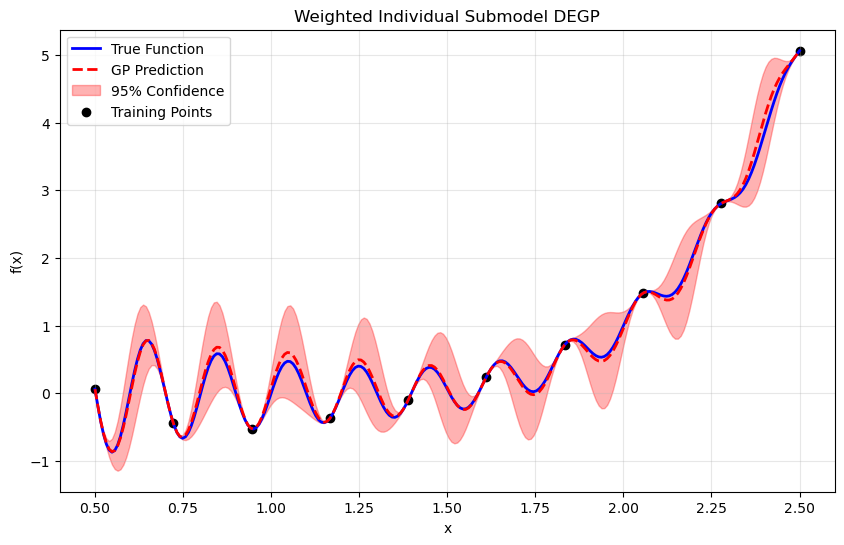

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')
plt.scatter(X_train, y_function_values, color='black', label='Training Points')
plt.title("Weighted Individual Submodel DEGP")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

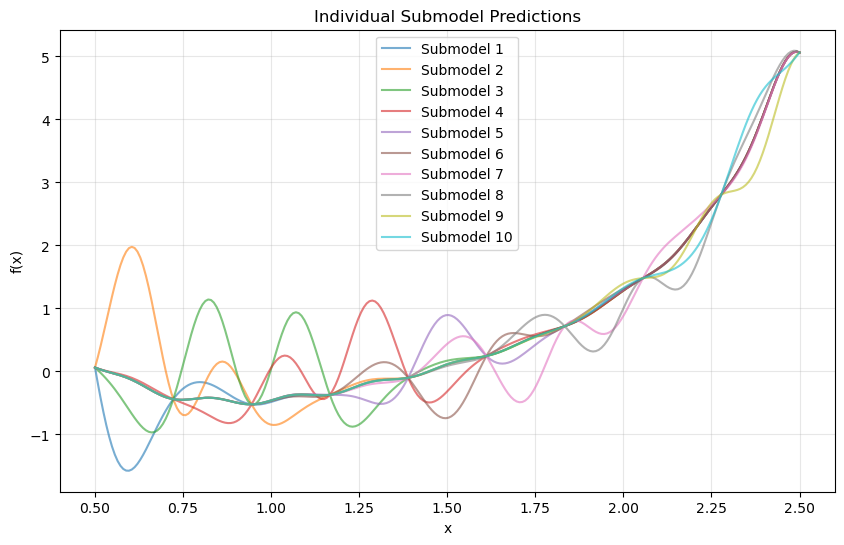

In [12]:
colors = plt.cm.tab10(np.linspace(0, 1, len(submodel_vals)))
plt.figure(figsize=(10, 6))
for i, color in enumerate(colors):
    plt.plot(X_test.flatten(), submodel_vals[i].flatten(), color=color, alpha=0.6, label=f'Submodel {i+1}')
plt.title("Individual Submodel Predictions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from jetgp.wdegp.wdegp import wdegp
import jetgp.utils as utils

In [14]:
n_order = 2
n_bases = 1
lb_x = 0.5
ub_x = 2.5
num_points = 10

In [15]:
x = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x) / (2 * x) + (x - 1)**4

f1_sym = sp.diff(f_sym, x)
f2_sym = sp.diff(f_sym, x, 2)

f_fun = sp.lambdify(x, f_sym, "numpy")
f1_fun = sp.lambdify(x, f1_sym, "numpy")
f2_fun = sp.lambdify(x, f2_sym, "numpy")

In [16]:
X_train = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)
print("Training points:", X_train.ravel())

Training points: [0.5        0.72222222 0.94444444 1.16666667 1.38888889 1.61111111
 1.83333333 2.05555556 2.27777778 2.5       ]


In [17]:
# Sparse derivative selection: only include derivatives at these points
# Note: Indices do NOT need to be contiguous!
derivative_indices = [2, 3, 4, 5]

# Single submodel with derivatives at the selected points
# Structure: [[indices for 1st order, indices for 2nd order]]
submodel_indices = [[derivative_indices, derivative_indices]]

# Derivative specs: 1st and 2nd order for this submodel
derivative_specs = [utils.gen_OTI_indices(n_bases, n_order)]

print(f"Number of submodels: {len(submodel_indices)}")
print(f"Derivative observation points: {derivative_indices}")
print(f"submodel_indices structure: {submodel_indices}")
print(f"derivative_specs: {derivative_specs}")

Number of submodels: 1
Derivative observation points: [2, 3, 4, 5]
submodel_indices structure: [[[2, 3, 4, 5], [2, 3, 4, 5]]]
derivative_specs: [[[[[1, 1]]], [[[1, 2]]]]]


In [18]:
# Function values at all training points
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

# Derivatives only at selected points
d1_sparse = np.array([[f1_fun(X_train[idx, 0])] for idx in derivative_indices])
d2_sparse = np.array([[f2_fun(X_train[idx, 0])] for idx in derivative_indices])

# Submodel data: [function values at ALL points, derivs at selected points]
submodel_data = [[y_function_values, d1_sparse, d2_sparse]]

print(f"Function values shape: {y_function_values.shape} (all {num_points} points)")
print(f"1st derivatives shape: {d1_sparse.shape} (only {len(derivative_indices)} points)")
print(f"2nd derivatives shape: {d2_sparse.shape} (only {len(derivative_indices)} points)")

Function values shape: (10, 1) (all 10 points)
1st derivatives shape: (4, 1) (only 4 points)
2nd derivatives shape: (4, 1) (only 4 points)


In [19]:
kernel = "SE"
kernel_type = "anisotropic"
normalize = True

gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    derivative_specs,
    derivative_locations=submodel_indices,
    normalize=normalize,
    kernel=kernel,
    kernel_type=kernel_type
)

In [20]:
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = 15,
    debug = False
    )
print("\nOptimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15

Optimized hyperparameters: [  0.86638921  -0.05256754 -14.65779265]


In [21]:
X_test = np.linspace(lb_x, ub_x, 250).reshape(-1, 1)
y_pred, y_cov = gp_model.predict(X_test, params, calc_cov=True)
y_true = f_fun(X_test.flatten())
nrmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2)) / (y_true.max() - y_true.min())
print(f"\nNRMSE: {nrmse:.6f}")


NRMSE: 0.055107


In [22]:
# Verify function value interpolation at all training points
y_pred_func = gp_model.predict(X_train, params, calc_cov=False)

print("Function value interpolation errors:")
print("=" * 70)
for i in range(num_points):
    error_abs = abs(y_pred_func[0, i] - y_function_values[i, 0])
    status = "WITH derivs" if i in derivative_indices else "no derivs"
    print(f"Point {i} (x={X_train[i, 0]:.3f}, {status}): Abs Error = {error_abs:.2e}")

# Verify derivative interpolation at sparse points using return_deriv=True
# We query only the points where derivatives were provided
X_deriv_points = X_train[derivative_indices]
y_pred_with_derivs = gp_model.predict(X_deriv_points, params, calc_cov=False, return_deriv=True)

# Output structure: (num_deriv_types + 1, num_points)
# Row 0: function values, Row 1: 1st derivatives, Row 2: 2nd derivatives
print(f"\nPrediction shape with return_deriv=True: {y_pred_with_derivs.shape}")
print("  Row 0: function values")
print("  Row 1: first derivatives")
print("  Row 2: second derivatives")

print("\n" + "=" * 70)
print(f"Derivative verification at sparse points {derivative_indices} using return_deriv=True:")
print("=" * 70)

# Extract predictions - each row is a different output type
pred_func = y_pred_with_derivs[0, :]   # Function values
pred_d1 = y_pred_with_derivs[1, :]     # First derivatives
pred_d2 = y_pred_with_derivs[2, :]     # Second derivatives

print("\nFirst derivative interpolation (direct from GP):")
for local_idx, global_idx in enumerate(derivative_indices):
    analytic = d1_sparse[local_idx, 0]
    predicted = pred_d1[local_idx]
    error = abs(predicted - analytic)
    rel_error = error / abs(analytic) if analytic != 0 else error
    print(f"  Point {global_idx} (x={X_train[global_idx, 0]:.3f}): Pred={predicted:.6f}, Analytic={analytic:.6f}, Rel Error={rel_error:.2e}")

print("\nSecond derivative interpolation (direct from GP):")
for local_idx, global_idx in enumerate(derivative_indices):
    analytic = d2_sparse[local_idx, 0]
    predicted = pred_d2[local_idx]
    error = abs(predicted - analytic)
    rel_error = error / abs(analytic) if analytic != 0 else error
    print(f"  Point {global_idx} (x={X_train[global_idx, 0]:.3f}): Pred={predicted:.6f}, Analytic={analytic:.6f}, Rel Error={rel_error:.2e}")

print("\n" + "=" * 70)
print("Note: Derivative predictions are only available at points where derivatives")
print("      were used in training. For other points, use finite differences.")
print("=" * 70)

Function value interpolation errors:
Point 0 (x=0.500, no derivs): Abs Error = 3.89e-16
Point 1 (x=0.722, no derivs): Abs Error = 3.89e-16
Point 2 (x=0.944, WITH derivs): Abs Error = 1.11e-16
Point 3 (x=1.167, WITH derivs): Abs Error = 2.22e-16
Point 4 (x=1.389, WITH derivs): Abs Error = 2.50e-16
Point 5 (x=1.611, WITH derivs): Abs Error = 1.67e-16
Point 6 (x=1.833, no derivs): Abs Error = 0.00e+00
Point 7 (x=2.056, no derivs): Abs Error = 0.00e+00
Point 8 (x=2.278, no derivs): Abs Error = 4.44e-16
Point 9 (x=2.500, no derivs): Abs Error = 8.88e-16
Making predictions for all derivatives that are common among submodels

Prediction shape with return_deriv=True: (3, 4)
  Row 0: function values
  Row 1: first derivatives
  Row 2: second derivatives

Derivative verification at sparse points [2, 3, 4, 5] using return_deriv=True:

First derivative interpolation (direct from GP):
  Point 2 (x=0.944): Pred=519.554404, Analytic=-2.336758, Rel Error=2.23e+02
  Point 3 (x=1.167): Pred=354.561483, 

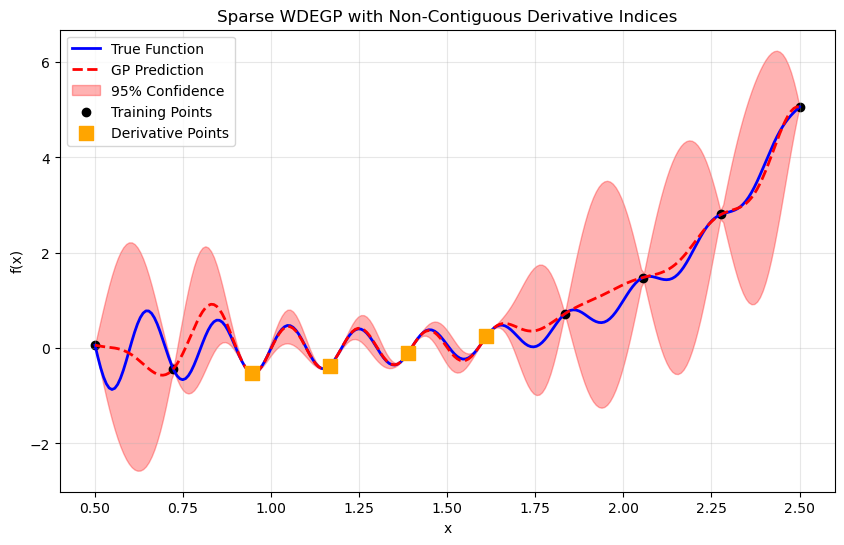

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')
plt.scatter(X_train, y_function_values, color='black', label='Training Points')
plt.scatter(X_train[derivative_indices], y_function_values[derivative_indices],
            color='orange', s=100, marker='s', label='Derivative Points', zorder=5)
plt.title("Sparse WDEGP with Non-Contiguous Derivative Indices")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [24]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from jetgp.wdegp.wdegp import wdegp
import jetgp.utils as utils

In [25]:
n_order = 2
n_bases = 1
lb_x = 0.5
ub_x = 2.5
num_points = 10

np.random.seed(42)

In [26]:
x = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x) / (2 * x) + (x - 1)**4

f1_sym = sp.diff(f_sym, x)
f2_sym = sp.diff(f_sym, x, 2)

f_fun = sp.lambdify(x, f_sym, "numpy")
f1_fun = sp.lambdify(x, f1_sym, "numpy")
f2_fun = sp.lambdify(x, f2_sym, "numpy")

In [27]:
X_train = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)
print("Training points:", X_train.ravel())

Training points: [0.5        0.72222222 0.94444444 1.16666667 1.38888889 1.61111111
 1.83333333 2.05555556 2.27777778 2.5       ]


In [28]:
# Submodel 0: derivatives at even indices [0, 2, 4, 6, 8]
# Submodel 1: derivatives at odd indices [1, 3, 5, 7, 9]
submodel0_indices = [0, 2, 4, 6, 8]
submodel1_indices = [1, 3, 5, 7, 9]

# Structure: submodel_indices[submodel_idx][deriv_type_idx] = list of point indices
# Both derivative types (1st and 2nd order) use the same indices within each submodel
submodel_indices = [
    [submodel0_indices, submodel0_indices],  # Submodel 0: both deriv types at [0,2,4,6,8]
    [submodel1_indices, submodel1_indices]   # Submodel 1: both deriv types at [1,3,5,7,9]
]

# Both submodels use the same derivative specifications
# This enables return_deriv=True for the weighted model!
base_deriv_specs = utils.gen_OTI_indices(n_bases, n_order)
derivative_specs = [base_deriv_specs, base_deriv_specs]

print(f"Number of submodels: {len(submodel_indices)}")
print(f"Submodel 0 derivative indices: {submodel0_indices}")
print(f"Submodel 1 derivative indices: {submodel1_indices}")
print(f"\nsubmodel_indices structure:")
print(f"  Submodel 0: {submodel_indices[0]}")
print(f"  Submodel 1: {submodel_indices[1]}")
print(f"\nderivative_specs (same for both): {derivative_specs[0]}")
print(f"\nSince both submodels share derivative_specs, return_deriv=True is available!")

Number of submodels: 2
Submodel 0 derivative indices: [0, 2, 4, 6, 8]
Submodel 1 derivative indices: [1, 3, 5, 7, 9]

submodel_indices structure:
  Submodel 0: [[0, 2, 4, 6, 8], [0, 2, 4, 6, 8]]
  Submodel 1: [[1, 3, 5, 7, 9], [1, 3, 5, 7, 9]]

derivative_specs (same for both): [[[[1, 1]]], [[[1, 2]]]]

Since both submodels share derivative_specs, return_deriv=True is available!


In [29]:
# Function values at ALL training points (shared by both submodels)
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

# Submodel 0: derivatives at even indices
d1_submodel0 = np.array([[f1_fun(X_train[idx, 0])] for idx in submodel0_indices])
d2_submodel0 = np.array([[f2_fun(X_train[idx, 0])] for idx in submodel0_indices])

# Submodel 1: derivatives at odd indices
d1_submodel1 = np.array([[f1_fun(X_train[idx, 0])] for idx in submodel1_indices])
d2_submodel1 = np.array([[f2_fun(X_train[idx, 0])] for idx in submodel1_indices])

# Package data for each submodel
# Each gets: [function values at ALL points, derivs at its points]
submodel_data = [
    [y_function_values, d1_submodel0, d2_submodel0],  # Submodel 0
    [y_function_values, d1_submodel1, d2_submodel1]   # Submodel 1
]

print("Submodel data structure:")
print(f"  Submodel 0: func vals ({y_function_values.shape}), d1 ({d1_submodel0.shape}), d2 ({d2_submodel0.shape})")
print(f"  Submodel 1: func vals ({y_function_values.shape}), d1 ({d1_submodel1.shape}), d2 ({d2_submodel1.shape})")

Submodel data structure:
  Submodel 0: func vals ((10, 1)), d1 ((5, 1)), d2 ((5, 1))
  Submodel 1: func vals ((10, 1)), d1 ((5, 1)), d2 ((5, 1))


In [30]:
kernel = "SE"
kernel_type = "anisotropic"
normalize = True

gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    derivative_specs,
    derivative_locations = submodel_indices,
    normalize=normalize,
    kernel=kernel,
    kernel_type=kernel_type
)

In [31]:
params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = False
    )
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [  0.80070968  -0.0155638  -11.31465273]


In [32]:
X_test = np.linspace(lb_x, ub_x, 250).reshape(-1, 1)
y_pred, y_cov, submodel_vals, submodel_cov = gp_model.predict(
    X_test, params, calc_cov=True, return_submodels=True
)
y_true = f_fun(X_test.flatten())
nrmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2)) / (y_true.max() - y_true.min())
print(f"NRMSE: {nrmse:.6f}")

NRMSE: 0.008848


In [33]:
# Since both submodels share the same derivative_specs, we can use return_deriv=True
y_pred_train = gp_model.predict(X_train, params, calc_cov=False, return_deriv=True)

# Extract predictions - shape is (num_deriv_types + 1, num_points)
pred_func = y_pred_train[0, :]  # Function values
pred_d1 = y_pred_train[1, :]    # First derivatives
pred_d2 = y_pred_train[2, :]    # Second derivatives

# Compute analytic values
analytic_func = y_function_values.flatten()
analytic_d1 = np.array([f1_fun(X_train[i, 0]) for i in range(num_points)])
analytic_d2 = np.array([f2_fun(X_train[i, 0]) for i in range(num_points)])

print("=" * 70)
print("Interpolation verification using return_deriv=True:")
print("=" * 70)

print("\nFunction value interpolation (all points):")
for i in range(num_points):
    error = abs(pred_func[i] - analytic_func[i])
    submodel = "SM0" if i in submodel0_indices else "SM1"
    print(f"  Point {i} ({submodel}, x={X_train[i, 0]:.3f}): Error = {error:.2e}")

print("\nFirst derivative interpolation:")
print("  Submodel 0 points (even indices):")
for idx in submodel0_indices:
    rel_error = abs(pred_d1[idx] - analytic_d1[idx]) / abs(analytic_d1[idx]) if analytic_d1[idx] != 0 else abs(pred_d1[idx] - analytic_d1[idx])
    print(f"    Point {idx}: Pred={pred_d1[idx]:.6f}, Analytic={analytic_d1[idx]:.6f}, Rel Error={rel_error:.2e}")
print("  Submodel 1 points (odd indices):")
for idx in submodel1_indices:
    rel_error = abs(pred_d1[idx] - analytic_d1[idx]) / abs(analytic_d1[idx]) if analytic_d1[idx] != 0 else abs(pred_d1[idx] - analytic_d1[idx])
    print(f"    Point {idx}: Pred={pred_d1[idx]:.6f}, Analytic={analytic_d1[idx]:.6f}, Rel Error={rel_error:.2e}")

print("\nSecond derivative interpolation:")
print("  Submodel 0 points (even indices):")
for idx in submodel0_indices:
    rel_error = abs(pred_d2[idx] - analytic_d2[idx]) / abs(analytic_d2[idx]) if analytic_d2[idx] != 0 else abs(pred_d2[idx] - analytic_d2[idx])
    print(f"    Point {idx}: Pred={pred_d2[idx]:.6f}, Analytic={analytic_d2[idx]:.6f}, Rel Error={rel_error:.2e}")
print("  Submodel 1 points (odd indices):")
for idx in submodel1_indices:
    rel_error = abs(pred_d2[idx] - analytic_d2[idx]) / abs(analytic_d2[idx]) if analytic_d2[idx] != 0 else abs(pred_d2[idx] - analytic_d2[idx])
    print(f"    Point {idx}: Pred={pred_d2[idx]:.6f}, Analytic={analytic_d2[idx]:.6f}, Rel Error={rel_error:.2e}")

print("\n" + "=" * 70)
print("Summary:")
print(f"  Max function error: {np.max(np.abs(pred_func - analytic_func)):.2e}")
print(f"  Max 1st deriv error: {np.max(np.abs(pred_d1 - analytic_d1)):.2e}")
print(f"  Max 2nd deriv error: {np.max(np.abs(pred_d2 - analytic_d2)):.2e}")
print("=" * 70)

Making predictions for all derivatives that are common among submodels
Interpolation verification using return_deriv=True:

Function value interpolation (all points):
  Point 0 (SM0, x=0.500): Error = 5.55e-17
  Point 1 (SM1, x=0.722): Error = 1.67e-16
  Point 2 (SM0, x=0.944): Error = 0.00e+00
  Point 3 (SM1, x=1.167): Error = 0.00e+00
  Point 4 (SM0, x=1.389): Error = 6.94e-17
  Point 5 (SM1, x=1.611): Error = 5.55e-17
  Point 6 (SM0, x=1.833): Error = 4.44e-16
  Point 7 (SM1, x=2.056): Error = 4.44e-16
  Point 8 (SM0, x=2.278): Error = 4.44e-16
  Point 9 (SM1, x=2.500): Error = 8.88e-16

First derivative interpolation:
  Submodel 0 points (even indices):
    Point 0: Pred=128.663706, Analytic=-31.915927, Rel Error=5.03e+00
    Point 2: Pred=519.554404, Analytic=-2.336758, Rel Error=2.23e+02
    Point 4: Pred=107.905034, Analytic=10.951579, Rel Error=8.85e+00
    Point 6: Pred=-229.308517, Analytic=6.469975, Rel Error=3.64e+01
    Point 8: Pred=-114.974318, Analytic=3.000267, Rel Err

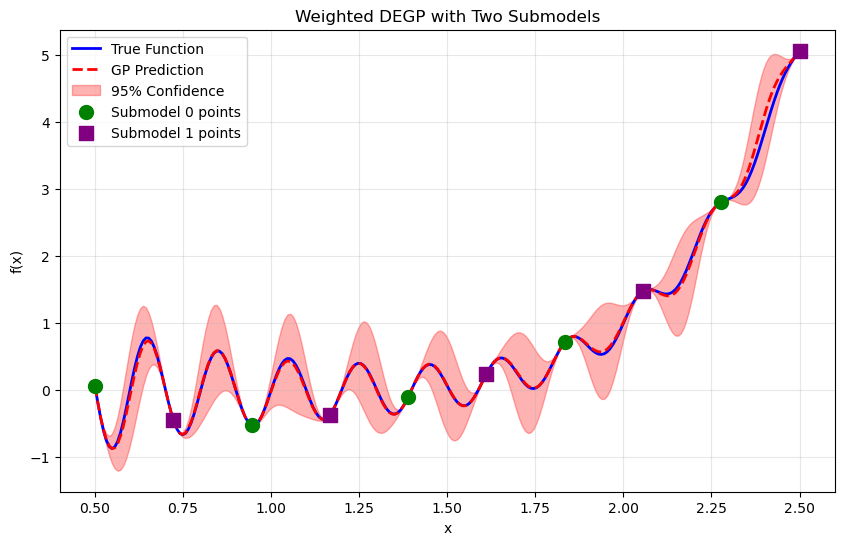

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')

# Show submodel points with different colors
plt.scatter(X_train[submodel0_indices], y_function_values[submodel0_indices],
            color='green', s=100, marker='o', label='Submodel 0 points', zorder=5)
plt.scatter(X_train[submodel1_indices], y_function_values[submodel1_indices],
            color='purple', s=100, marker='s', label='Submodel 1 points', zorder=5)

plt.title("Weighted DEGP with Two Submodels")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

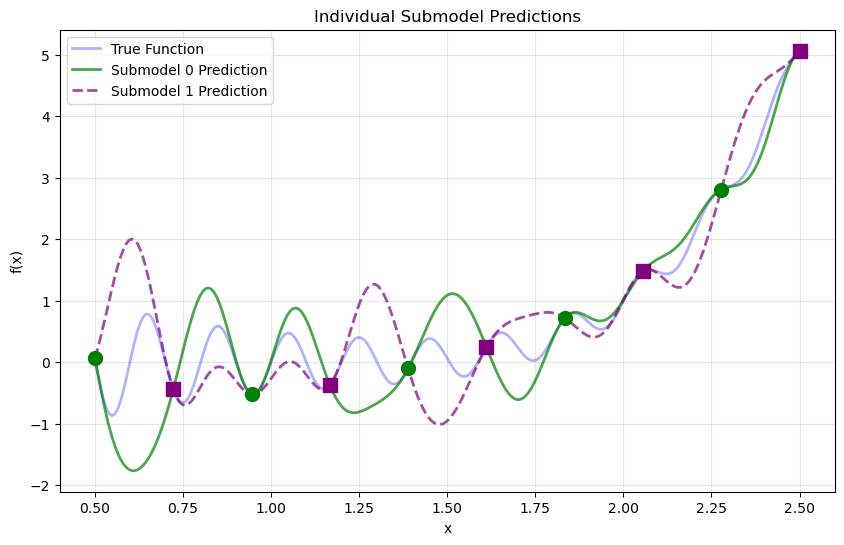

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2, alpha=0.3)
plt.plot(X_test.flatten(), submodel_vals[0].flatten(), 'g-',
         label='Submodel 0 Prediction', linewidth=2, alpha=0.7)
plt.plot(X_test.flatten(), submodel_vals[1].flatten(), 'purple', linestyle='--',
         label='Submodel 1 Prediction', linewidth=2, alpha=0.7)
plt.scatter(X_train[submodel0_indices], y_function_values[submodel0_indices],
            color='green', s=100, marker='o', zorder=5)
plt.scatter(X_train[submodel1_indices], y_function_values[submodel1_indices],
            color='purple', s=100, marker='s', zorder=5)
plt.title("Individual Submodel Predictions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from jetgp.wdegp.wdegp import wdegp
import jetgp.utils as utils

In [37]:
n_order = 2
n_bases = 1
lb_x = 0.5
ub_x = 2.5
num_points = 10

np.random.seed(42)

In [38]:
x = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x) / (2 * x) + (x - 1)**4

f1_sym = sp.diff(f_sym, x)
f2_sym = sp.diff(f_sym, x, 2)

f_fun = sp.lambdify(x, f_sym, "numpy")
f1_fun = sp.lambdify(x, f1_sym, "numpy")
f2_fun = sp.lambdify(x, f2_sym, "numpy")

In [39]:
X_train = np.linspace(lb_x, ub_x, num_points).reshape(-1, 1)
print("Training points:", X_train.ravel())

Training points: [0.5        0.72222222 0.94444444 1.16666667 1.38888889 1.61111111
 1.83333333 2.05555556 2.27777778 2.5       ]


In [40]:
# Submodel 0: 1st order derivs at [0,2,4,6,8], 2nd order derivs at [4,5,6]
# Submodel 1: 1st order derivs at [1,3,5,7,9], 2nd order derivs at [3,4,5]

# Note: Different indices for different derivative types within each submodel!
submodel_indices = [
    [[0, 2, 4, 6, 8], [2, 4, 6]],  # Submodel 0: 1st order at 5 pts, 2nd order at 3 pts
    [[1, 3, 5, 7, 9], [3, 7, 9]]   # Submodel 1: 1st order at 5 pts, 2nd order at 3 pts
    ]

# Both submodels still use the same derivative TYPES (1st and 2nd order)
# So return_deriv=True IS available in this case
derivative_specs = [
    [[[[1, 1]]], [[[1, 2]]]],  # Submodel 0: 1st order, 2nd order
    [[[[1, 1]]], [[[1, 2]]]]   # Submodel 1: 1st order, 2nd order
]

print("Submodel structure:")
print(f"  Submodel 0:")
print(f"    1st order derivs {derivative_specs[0][0]} at points {submodel_indices[0][0]}")
print(f"    2nd order derivs {derivative_specs[0][1]} at points {submodel_indices[0][1]}")
print(f"  Submodel 1:")
print(f"    1st order derivs {derivative_specs[1][0]} at points {submodel_indices[1][0]}")
print(f"    2nd order derivs {derivative_specs[1][1]} at points {submodel_indices[1][1]}")
print(f"\nBoth submodels use same derivative TYPES - return_deriv=True is available!")

Submodel structure:
  Submodel 0:
    1st order derivs [[[1, 1]]] at points [0, 2, 4, 6, 8]
    2nd order derivs [[[1, 2]]] at points [2, 4, 6]
  Submodel 1:
    1st order derivs [[[1, 1]]] at points [1, 3, 5, 7, 9]
    2nd order derivs [[[1, 2]]] at points [3, 7, 9]

Both submodels use same derivative TYPES - return_deriv=True is available!


In [41]:
# Function values at ALL training points
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

# Submodel 0 derivatives
d1_sm0_indices = submodel_indices[0][0]
d2_sm0_indices = submodel_indices[0][1]
d1_submodel0 = np.array([[f1_fun(X_train[idx, 0])] for idx in d1_sm0_indices])
d2_submodel0 = np.array([[f2_fun(X_train[idx, 0])] for idx in d2_sm0_indices])

# Submodel 1 derivatives
d1_sm1_indices = submodel_indices[1][0]
d2_sm1_indices = submodel_indices[1][1]
d1_submodel1 = np.array([[f1_fun(X_train[idx, 0])] for idx in d1_sm1_indices])
d2_submodel1 = np.array([[f2_fun(X_train[idx, 0])] for idx in d2_sm1_indices])

# Package data
submodel_data = [
    [y_function_values, d1_submodel0, d2_submodel0],
    [y_function_values, d1_submodel1, d2_submodel1]
]

print("Submodel data structure:")
print(f"  Submodel 0: func ({y_function_values.shape}), d1 ({d1_submodel0.shape}), d2 ({d2_submodel0.shape})")
print(f"  Submodel 1: func ({y_function_values.shape}), d1 ({d1_submodel1.shape}), d2 ({d2_submodel1.shape})")

Submodel data structure:
  Submodel 0: func ((10, 1)), d1 ((5, 1)), d2 ((3, 1))
  Submodel 1: func ((10, 1)), d1 ((5, 1)), d2 ((3, 1))


In [42]:
gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    derivative_specs,
    derivative_locations =submodel_indices,
    normalize=True,
    kernel="SE",
    kernel_type="anisotropic"
)

params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size=100,
    n_generations=15,
    debug=False
)
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [ 7.98000872e-01 -3.45101374e-03 -1.09200999e+01]


In [43]:
X_test = np.linspace(lb_x, ub_x, 250).reshape(-1, 1)
y_pred, y_cov = gp_model.predict(X_test, params, calc_cov=True)
y_true = f_fun(X_test.flatten())
nrmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2)) / (y_true.max() - y_true.min())
print(f"NRMSE: {nrmse:.6f}")

# Verify using return_deriv=True (available because derivative_specs match)
y_pred_train = gp_model.predict(X_train, params, calc_cov=False, return_deriv=True)

# Extract predictions - shape is (num_deriv_types + 1, num_points)
pred_func = y_pred_train[0, :]  # Function values
pred_d1 = y_pred_train[1, :]    # First derivatives
pred_d2 = y_pred_train[2, :]    # Second derivatives

# Compute analytic values
analytic_func = y_function_values.flatten()
analytic_d1 = np.array([f1_fun(X_train[i, 0]) for i in range(num_points)])
analytic_d2 = np.array([f2_fun(X_train[i, 0]) for i in range(num_points)])

print("\n" + "=" * 70)
print("Verification using return_deriv=True:")
print("=" * 70)
print(f"Max function error: {np.max(np.abs(pred_func - analytic_func)):.2e}")
print(f"Max 1st deriv error: {np.max(np.abs(pred_d1 - analytic_d1)):.2e}")
print(f"Max 2nd deriv error: {np.max(np.abs(pred_d2 - analytic_d2)):.2e}")

print("\nSubmodel 0 derivative verification:")
print(f"  1st order at {d1_sm0_indices}:")
for idx in d1_sm0_indices:
    rel_err = abs(pred_d1[idx] - analytic_d1[idx]) / abs(analytic_d1[idx]) if analytic_d1[idx] != 0 else abs(pred_d1[idx] - analytic_d1[idx])
    print(f"    Point {idx}: Rel Error = {rel_err:.2e}")
print(f"  2nd order at {d2_sm0_indices}:")
for idx in d2_sm0_indices:
    rel_err = abs(pred_d2[idx] - analytic_d2[idx]) / abs(analytic_d2[idx]) if analytic_d2[idx] != 0 else abs(pred_d2[idx] - analytic_d2[idx])
    print(f"    Point {idx}: Rel Error = {rel_err:.2e}")

print("\nSubmodel 1 derivative verification:")
print(f"  1st order at {d1_sm1_indices}:")
for idx in d1_sm1_indices:
    rel_err = abs(pred_d1[idx] - analytic_d1[idx]) / abs(analytic_d1[idx]) if analytic_d1[idx] != 0 else abs(pred_d1[idx] - analytic_d1[idx])
    print(f"    Point {idx}: Rel Error = {rel_err:.2e}")
print(f"  2nd order at {d2_sm1_indices}:")
for idx in d2_sm1_indices:
    rel_err = abs(pred_d2[idx] - analytic_d2[idx]) / abs(analytic_d2[idx]) if analytic_d2[idx] != 0 else abs(pred_d2[idx] - analytic_d2[idx])
    print(f"    Point {idx}: Rel Error = {rel_err:.2e}")

NRMSE: 0.043772
Making predictions for all derivatives that are common among submodels

Verification using return_deriv=True:
Max function error: 7.77e-16
Max 1st deriv error: 5.22e+02
Max 2nd deriv error: 5.22e+02

Submodel 0 derivative verification:
  1st order at [0, 2, 4, 6, 8]:
    Point 0: Rel Error = 1.15e+00
    Point 2: Rel Error = 2.23e+02
    Point 4: Rel Error = 8.85e+00
    Point 6: Rel Error = 3.64e+01
    Point 8: Rel Error = 7.80e+00
  2nd order at [2, 4, 6]:
    Point 2: Rel Error = 1.00e+00
    Point 4: Rel Error = 8.99e-01
    Point 6: Rel Error = 1.03e+00

Submodel 1 derivative verification:
  1st order at [1, 3, 5, 7, 9]:
    Point 1: Rel Error = 2.22e+00
    Point 3: Rel Error = 4.92e+01
    Point 5: Rel Error = 7.71e-01
    Point 7: Rel Error = 6.90e+01
    Point 9: Rel Error = 3.44e+00
  2nd order at [3, 7, 9]:
    Point 3: Rel Error = 9.80e-01
    Point 7: Rel Error = 1.01e+00
    Point 9: Rel Error = 7.75e-01


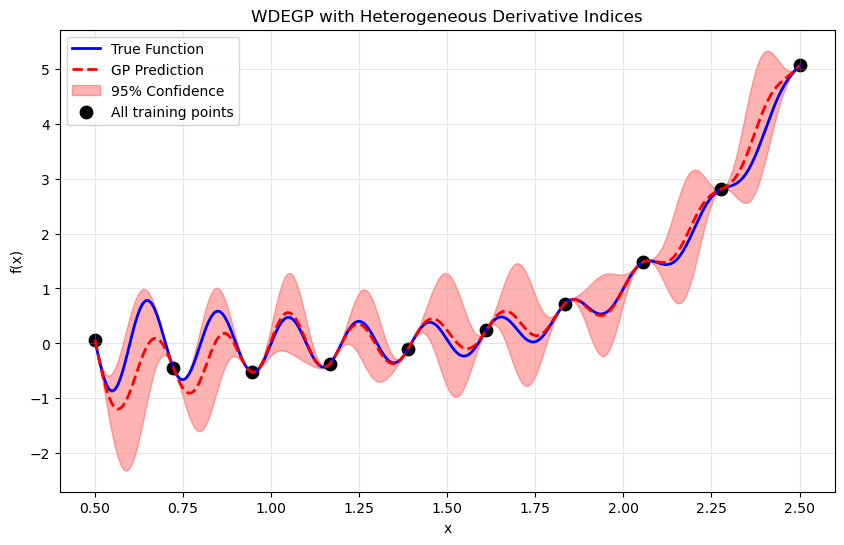

In [44]:
plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')
plt.scatter(X_train, y_function_values, color='black', s=80, label='All training points')
plt.title("WDEGP with Heterogeneous Derivative Indices")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from jetgp.wdegp.wdegp import wdegp
import jetgp.utils as utils

x = sp.symbols('x')
f_sym = sp.sin(10 * sp.pi * x) / (2 * x) + (x - 1)**4
f1_sym = sp.diff(f_sym, x)
f2_sym = sp.diff(f_sym, x, 2)

f_fun = sp.lambdify(x, f_sym, "numpy")
f1_fun = sp.lambdify(x, f1_sym, "numpy")
f2_fun = sp.lambdify(x, f2_sym, "numpy")

n_order = 2
n_bases = 1
num_points = 10
X_train = np.linspace(0.5, 2.5, num_points).reshape(-1, 1)
y_function_values = f_fun(X_train.flatten()).reshape(-1, 1)

In [46]:
# Submodel 0: ONLY 1st order derivatives
# Submodel 1: ONLY 2nd order derivatives
# These are DIFFERENT derivative specs - return_deriv=True NOT available!

submodel_indices = [
    [[0, 2, 4, 6, 8]],      # Submodel 0: only has 1st order
    [[1, 3, 5, 7, 9]]       # Submodel 1: only has 2nd order
]

derivative_specs = [
    [[[[1, 1]]]],             # Submodel 0: only 1st order derivatives
    [[[[1, 2]]]]              # Submodel 1: only 2nd order derivatives
]

print("Submodel structure with DIFFERENT derivative specs:")
print(f"  Submodel 0: {derivative_specs[0]} at {submodel_indices[0][0]}")
print(f"  Submodel 1: {derivative_specs[1]} at {submodel_indices[1][0]}")
print(f"\nWARNING: No shared derivatives - return_deriv=True NOT available!")
print("Must use finite differences for derivative verification on weighted model,")
print("or access individual submodels via return_submodels=True.")

Submodel structure with DIFFERENT derivative specs:
  Submodel 0: [[[[1, 1]]]] at [0, 2, 4, 6, 8]
  Submodel 1: [[[[1, 2]]]] at [1, 3, 5, 7, 9]

Must use finite differences for derivative verification on weighted model,
or access individual submodels via return_submodels=True.


In [47]:
# Compute derivatives for each submodel
d1_submodel0 = np.array([[f1_fun(X_train[idx, 0])] for idx in submodel_indices[0][0]])
d2_submodel1 = np.array([[f2_fun(X_train[idx, 0])] for idx in submodel_indices[1][0]])

submodel_data = [
    [y_function_values, d1_submodel0],      # Submodel 0: func + 1st derivs only
    [y_function_values, d2_submodel1]       # Submodel 1: func + 2nd derivs only
]

gp_model = wdegp(
    X_train,
    submodel_data,
    n_order,
    n_bases,
    derivative_specs,
    derivative_locations = submodel_indices,
    normalize=True,
    kernel="SE",
    kernel_type="anisotropic"
)

params = gp_model.optimize_hyperparameters(
    optimizer='jade', pop_size=100, n_generations=15, debug=False
)

In [48]:
print("=" * 70)
print("Verification using FINITE DIFFERENCES (return_deriv not available)")
print("=" * 70)

h = 1e-6

# Verify 1st derivatives on Submodel 0 points using individual submodel
print("\nSubmodel 0 - 1st derivative verification (via individual submodel):")
for local_idx, global_idx in enumerate(submodel_indices[0][0]):
    x_pt = X_train[global_idx, 0]

    X_plus = np.array([[x_pt + h]])
    X_minus = np.array([[x_pt - h]])

    _, sm_plus = gp_model.predict(X_plus, params, return_submodels=True)
    _, sm_minus = gp_model.predict(X_minus, params, return_submodels=True)

    # Use Submodel 0 predictions
    fd_d1 = (sm_plus[0][0, 0] - sm_minus[0][0, 0]) / (2 * h)
    analytic_d1 = d1_submodel0[local_idx, 0]
    rel_error = abs(fd_d1 - analytic_d1) / abs(analytic_d1) if analytic_d1 != 0 else abs(fd_d1 - analytic_d1)

    print(f"  Point {global_idx}: FD={fd_d1:.6f}, Analytic={analytic_d1:.6f}, Rel Error={rel_error:.2e}")

# Verify 2nd derivatives on Submodel 1 points using individual submodel
print("\nSubmodel 1 - 2nd derivative verification (via individual submodel):")
for local_idx, global_idx in enumerate(submodel_indices[1][0]):
    x_pt = X_train[global_idx, 0]

    X_plus = np.array([[x_pt + h]])
    X_minus = np.array([[x_pt - h]])
    X_center = np.array([[x_pt]])

    _, sm_plus = gp_model.predict(X_plus, params, return_submodels=True)
    _, sm_minus = gp_model.predict(X_minus, params, return_submodels=True)
    _, sm_center = gp_model.predict(X_center, params, return_submodels=True)

    # Use Submodel 1 predictions
    fd_d2 = (sm_plus[1][0, 0] - 2*sm_center[1][0, 0] + sm_minus[1][0, 0]) / (h**2)
    analytic_d2 = d2_submodel1[local_idx, 0]
    rel_error = abs(fd_d2 - analytic_d2) / abs(analytic_d2) if analytic_d2 != 0 else abs(fd_d2 - analytic_d2)

    print(f"  Point {global_idx}: FD={fd_d2:.6f}, Analytic={analytic_d2:.6f}, Rel Error={rel_error:.2e}")

Verification using FINITE DIFFERENCES (return_deriv not available)

Submodel 0 - 1st derivative verification (via individual submodel):
  Point 0: FD=-31.915927, Analytic=-31.915927, Rel Error=4.70e-11
  Point 2: FD=-2.336758, Analytic=-2.336758, Rel Error=1.01e-10
  Point 4: FD=10.951579, Analytic=10.951579, Rel Error=1.26e-10
  Point 6: FD=6.469975, Analytic=6.469975, Rel Error=9.00e-11
  Point 8: FD=3.000267, Analytic=3.000267, Rel Error=3.29e-10

Submodel 1 - 2nd derivative verification (via individual submodel):
  Point 1: FD=484.562390, Analytic=484.562101, Rel Error=5.98e-07
  Point 3: FD=354.561713, Analytic=354.561483, Rel Error=6.49e-07
  Point 5: FD=-111.570198, Analytic=-111.570095, Rel Error=9.16e-07
  Point 7: FD=-221.650254, Analytic=-221.649371, Rel Error=3.98e-06
  Point 9: FD=32.025049, Analytic=32.026548, Rel Error=4.68e-05


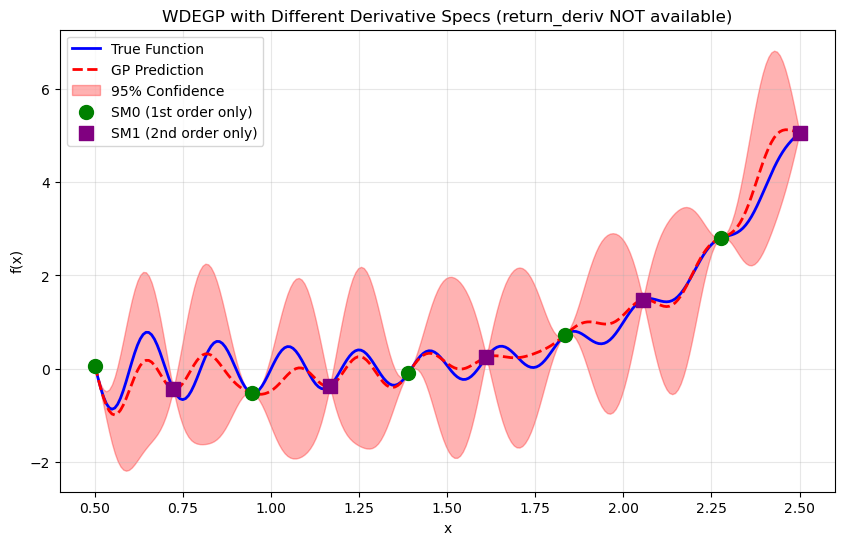

In [49]:
X_test = np.linspace(0.5, 2.5, 250).reshape(-1, 1)
y_pred, y_cov = gp_model.predict(X_test, params, calc_cov=True)
y_true = f_fun(X_test.flatten())

plt.figure(figsize=(10, 6))
plt.plot(X_test, y_true, 'b-', label='True Function', linewidth=2)
plt.plot(X_test.flatten(), y_pred.flatten(), 'r--', label='GP Prediction', linewidth=2)
plt.fill_between(X_test.ravel(),
                 (y_pred.flatten() - 2*np.sqrt(y_cov)).ravel(),
                 (y_pred.flatten() + 2*np.sqrt(y_cov)).ravel(),
                 color='red', alpha=0.3, label='95% Confidence')
plt.scatter(X_train[submodel_indices[0][0]], y_function_values[submodel_indices[0][0]],
            color='green', s=100, marker='o', label='SM0 (1st order only)', zorder=5)
plt.scatter(X_train[submodel_indices[1][0]], y_function_values[submodel_indices[1][0]],
            color='purple', s=100, marker='s', label='SM1 (2nd order only)', zorder=5)
plt.title("WDEGP with Different Derivative Specs (return_deriv NOT available)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from jetgp.wdegp.wdegp import wdegp
import jetgp.utils as utils

In [51]:
def f_2d(X):
    """2D test function: f(x,y) = sin(πx)cos(πy) + 0.5*x*y"""
    return np.sin(np.pi * X[:, 0]) * np.cos(np.pi * X[:, 1]) + 0.5 * X[:, 0] * X[:, 1]

def grad_f_2d(X):
    """Gradient of f: [∂f/∂x, ∂f/∂y]"""
    dfdx = np.pi * np.cos(np.pi * X[:, 0]) * np.cos(np.pi * X[:, 1]) + 0.5 * X[:, 1]
    dfdy = -np.pi * np.sin(np.pi * X[:, 0]) * np.sin(np.pi * X[:, 1]) + 0.5 * X[:, 0]
    return np.column_stack([dfdx, dfdy])

def directional_deriv(X, ray):
    """Compute directional derivative along ray direction: ∇f · ray"""
    grad = grad_f_2d(X)
    return grad @ ray

In [52]:
n_bases = 2      # 2D problem
n_order = 1      # First-order directional derivatives
num_points = 25  # 5x5 grid

np.random.seed(42)

# Create training grid
x1 = np.linspace(-1, 1, 5)
x2 = np.linspace(-1, 1, 5)
X1, X2 = np.meshgrid(x1, x2)
X_train = np.column_stack([X1.ravel(), X2.ravel()])

print(f"Training points shape: {X_train.shape}")
print(f"Number of training points: {num_points}")

Training points shape: (25, 2)
Number of training points: 25


In [53]:
# Global rays at 45° and -45° from x-axis
# These diagonal directions capture sensitivity along the domain's diagonals
angle_1 = np.pi / 4    # 45 degrees
angle_2 = -np.pi / 4   # -45 degrees

# Shape: (n_bases, n_directions) = (2, 2)
rays = np.array([
    [np.cos(angle_1), np.cos(angle_2)],   # x-components
    [np.sin(angle_1), np.sin(angle_2)]    # y-components
])

print("Global rays (shared by all submodels):")
print(f"  Ray 0 (+45°): [{rays[0, 0]:.4f}, {rays[1, 0]:.4f}]")
print(f"  Ray 1 (-45°): [{rays[0, 1]:.4f}, {rays[1, 1]:.4f}]")
print(f"\nRay norms: {np.linalg.norm(rays[:, 0]):.4f}, {np.linalg.norm(rays[:, 1]):.4f}")

Global rays (shared by all submodels):
  Ray 0 (+45°): [0.7071, 0.7071]
  Ray 1 (-45°): [0.7071, -0.7071]

Ray norms: 1.0000, 1.0000


In [54]:
# Partition points by distance from origin: inner vs outer
distances = np.linalg.norm(X_train, axis=1)
median_dist = np.median(distances)

sm1_indices = [i for i in range(num_points) if distances[i] <= median_dist]  # Inner points
sm2_indices = [i for i in range(num_points) if distances[i] > median_dist]   # Outer points

print(f"Submodel 1 indices (inner, dist ≤ {median_dist:.2f}): {sm1_indices}")
print(f"  Points: {len(sm1_indices)}")
print(f"Submodel 2 indices (outer, dist > {median_dist:.2f}): {sm2_indices}")
print(f"  Points: {len(sm2_indices)}")

# Verify disjoint
assert len(set(sm1_indices) & set(sm2_indices)) == 0, "Indices must be disjoint!"
print("\n✓ Indices are disjoint across submodels")

# Derivative locations: both directional derivatives at each submodel's points
# Structure: derivative_locations[submodel_idx][direction_idx] = point indices
derivative_locations = [
    [sm1_indices, sm1_indices],  # Submodel 1: both rays at inner points
    [sm2_indices, sm2_indices]   # Submodel 2: both rays at outer points
]

# Both submodels use the same derivative specifications (1st order directional)
der_indices = [
    [[[[1, 1]]], [[[2, 1]]]],   # Submodel 1: 1st order along ray 0, 1st order along ray 1
    [[[[1, 1]]], [[[2, 1]]]]    # Submodel 2: same structure
]

print(f"\nderivative_locations structure:")
print(f"  Submodel 1: ray 0 at {len(sm1_indices)} pts, ray 1 at {len(sm1_indices)} pts")
print(f"  Submodel 2: ray 0 at {len(sm2_indices)} pts, ray 1 at {len(sm2_indices)} pts")

Submodel 1 indices (inner, dist ≤ 1.00): [2, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18, 22]
  Points: 13
Submodel 2 indices (outer, dist > 1.00): [0, 1, 3, 4, 5, 9, 15, 19, 20, 21, 23, 24]
  Points: 12

✓ Indices are disjoint across submodels

derivative_locations structure:
  Submodel 1: ray 0 at 13 pts, ray 1 at 13 pts
  Submodel 2: ray 0 at 12 pts, ray 1 at 12 pts


In [55]:
# Function values at ALL training points (shared by both submodels)
y_function_values = f_2d(X_train).reshape(-1, 1)

# Compute directional derivatives along each ray
ray_0 = rays[:, 0]  # +45° direction
ray_1 = rays[:, 1]  # -45° direction

# Submodel 1: directional derivatives at inner points
X_sm1 = X_train[sm1_indices]
dd_ray0_sm1 = directional_deriv(X_sm1, ray_0).reshape(-1, 1)
dd_ray1_sm1 = directional_deriv(X_sm1, ray_1).reshape(-1, 1)

# Submodel 2: directional derivatives at outer points
X_sm2 = X_train[sm2_indices]
dd_ray0_sm2 = directional_deriv(X_sm2, ray_0).reshape(-1, 1)
dd_ray1_sm2 = directional_deriv(X_sm2, ray_1).reshape(-1, 1)

# Package data for WDEGP
# Structure: y_train[submodel_idx] = [func_vals, deriv_ray0, deriv_ray1, ...]
y_train = [
    [y_function_values, dd_ray0_sm1, dd_ray1_sm1],  # Submodel 1
    [y_function_values, dd_ray0_sm2, dd_ray1_sm2]   # Submodel 2
]

print("Data structure:")
print(f"  Function values: {y_function_values.shape} (shared)")
print(f"  Submodel 1 derivs: ray0 {dd_ray0_sm1.shape}, ray1 {dd_ray1_sm1.shape}")
print(f"  Submodel 2 derivs: ray0 {dd_ray0_sm2.shape}, ray1 {dd_ray1_sm2.shape}")

Data structure:
  Function values: (25, 1) (shared)
  Submodel 1 derivs: ray0 (13, 1), ray1 (13, 1)
  Submodel 2 derivs: ray0 (12, 1), ray1 (12, 1)


In [56]:
gp_model = wdegp(
    X_train,
    y_train,
    n_order,
    n_bases,
    der_indices,
    derivative_locations=derivative_locations,
    submodel_type='ddegp',    # Use DDEGP submodels
    rays=rays,                 # Global rays shared by all submodels
    normalize=True,
    kernel="SE",
    kernel_type="anisotropic"
)

print("WDEGP model created with DDEGP submodels")
print(f"  submodel_type: 'ddegp'")
print(f"  rays shape: {rays.shape}")

WDEGP model created with DDEGP submodels
  submodel_type: 'ddegp'
  rays shape: (2, 2)


In [57]:
params = gp_model.optimize_hyperparameters(
    optimizer='lbfgs',
    n_restart_optimizer=10,
    debug=False
)
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [-2.76911983e-03  4.53677287e-02  4.15258948e-01 -1.29211637e+01]


In [58]:
# Create test grid
x1_test = np.linspace(-1, 1, 50)
x2_test = np.linspace(-1, 1, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.ravel(), X2_test.ravel()])

# Predict
y_pred, y_cov = gp_model.predict(X_test, params, calc_cov=True)
y_true = f_2d(X_test)

# Compute error
nrmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2)) / (y_true.max() - y_true.min())
max_error = np.max(np.abs(y_true - y_pred.flatten()))

print(f"NRMSE: {nrmse:.6f}")
print(f"Max absolute error: {max_error:.6e}")

NRMSE: 0.000994
Max absolute error: 1.280412e-02


In [59]:
# Verify function value interpolation
y_pred_train = gp_model.predict(X_train, params, calc_cov=False)

print("=" * 70)
print("Function value interpolation verification:")
print("=" * 70)

max_func_error = np.max(np.abs(y_pred_train.flatten() - y_function_values.flatten()))
print(f"Max function interpolation error: {max_func_error:.2e}")

# Verify directional derivative interpolation using return_deriv=True
# This works because both submodels share the same der_indices
y_pred_with_derivs = gp_model.predict(X_train, params, calc_cov=False, return_deriv=True)

print(f"\nPrediction shape with return_deriv=True: {y_pred_with_derivs.shape}")
print("  Row 0: function values")
print("  Row 1: directional derivative along ray 0 (+45°)")
print("  Row 2: directional derivative along ray 1 (-45°)")

# Compute analytic directional derivatives at all training points
dd_ray0_all = directional_deriv(X_train, ray_0)
dd_ray1_all = directional_deriv(X_train, ray_1)

pred_dd0 = y_pred_with_derivs[1, :]
pred_dd1 = y_pred_with_derivs[2, :]

print("\n" + "=" * 70)
print("Directional derivative interpolation verification:")
print("=" * 70)

print(f"\nRay 0 (+45°) derivatives:")
print(f"  Max error: {np.max(np.abs(pred_dd0 - dd_ray0_all)):.2e}")

print(f"\nRay 1 (-45°) derivatives:")
print(f"  Max error: {np.max(np.abs(pred_dd1 - dd_ray1_all)):.2e}")

# Show details for a few points
print("\nDetailed verification (first 5 points):")
for i in range(5):
    submodel = "SM1 (inner)" if i in sm1_indices else "SM2 (outer)"
    print(f"  Point {i} ({submodel}):")
    print(f"    Ray 0: Pred={pred_dd0[i]:.6f}, Analytic={dd_ray0_all[i]:.6f}, Error={abs(pred_dd0[i] - dd_ray0_all[i]):.2e}")
    print(f"    Ray 1: Pred={pred_dd1[i]:.6f}, Analytic={dd_ray1_all[i]:.6f}, Error={abs(pred_dd1[i] - dd_ray1_all[i]):.2e}")

Function value interpolation verification:
Max function interpolation error: 3.74e-13
Making predictions for all derivatives that are common among submodels

Prediction shape with return_deriv=True: (3, 25)
  Row 0: function values
  Row 1: directional derivative along ray 0 (+45°)
  Row 2: directional derivative along ray 1 (-45°)

Directional derivative interpolation verification:

Ray 0 (+45°) derivatives:
  Max error: 4.18e-13

Ray 1 (-45°) derivatives:
  Max error: 4.77e-13

Detailed verification (first 5 points):
  Point 0 (SM2 (outer)):
    Ray 0: Pred=1.514335, Analytic=1.514335, Error=2.71e-14
    Ray 1: Pred=2.221441, Analytic=2.221441, Error=1.95e-14
  Point 1 (SM2 (outer)):
    Ray 0: Pred=-0.530330, Analytic=-0.530330, Error=4.44e-15
    Ray 1: Pred=-0.176777, Analytic=-0.176777, Error=1.43e-14
  Point 2 (SM1 (inner)):
    Ray 0: Pred=-2.574995, Analytic=-2.574995, Error=4.18e-13
    Ray 1: Pred=-2.574995, Analytic=-2.574995, Error=1.37e-13
  Point 3 (SM2 (outer)):
    Ray

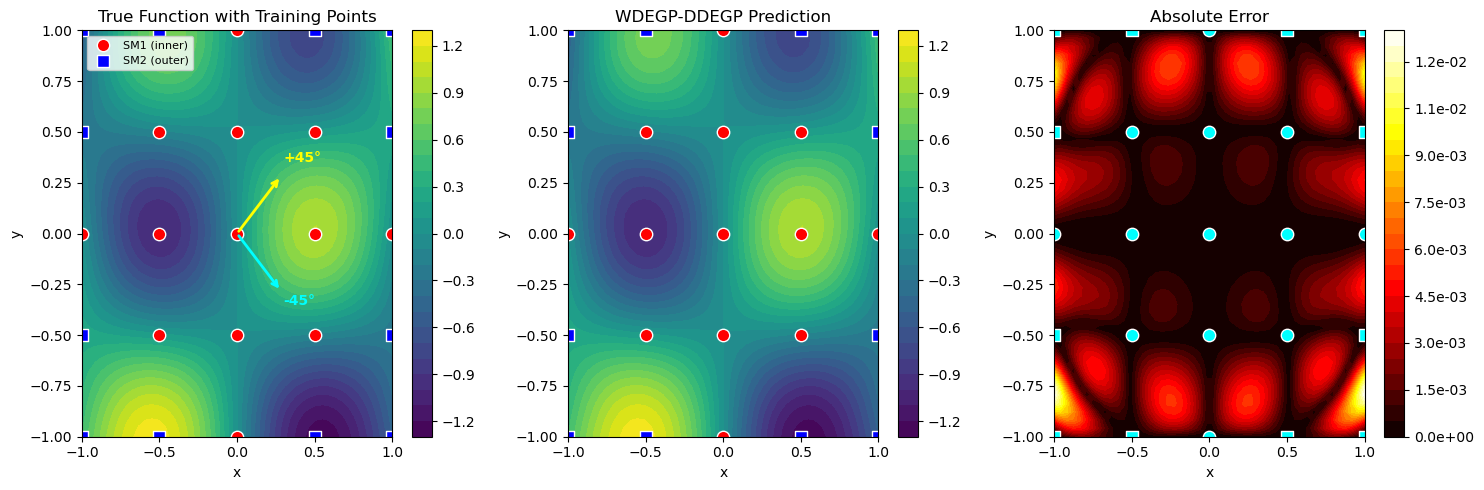

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Reshape for plotting
y_true_grid = y_true.reshape(50, 50)
y_pred_grid = y_pred.reshape(50, 50)
error_grid = np.abs(y_true_grid - y_pred_grid)

# True function
im0 = axes[0].contourf(X1_test, X2_test, y_true_grid, levels=30, cmap='viridis')
axes[0].scatter(X_train[sm1_indices, 0], X_train[sm1_indices, 1],
                c='red', s=80, marker='o', label='SM1 (inner)', edgecolors='white')
axes[0].scatter(X_train[sm2_indices, 0], X_train[sm2_indices, 1],
                c='blue', s=80, marker='s', label='SM2 (outer)', edgecolors='white')

# Add ray direction arrows at center
arrow_scale = 0.4
axes[0].annotate('', xy=(arrow_scale*ray_0[0], arrow_scale*ray_0[1]), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='yellow', lw=2))
axes[0].annotate('', xy=(arrow_scale*ray_1[0], arrow_scale*ray_1[1]), xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color='cyan', lw=2))
axes[0].text(0.3, 0.35, '+45°', color='yellow', fontsize=10, fontweight='bold')
axes[0].text(0.3, -0.35, '-45°', color='cyan', fontsize=10, fontweight='bold')

axes[0].set_title('True Function with Training Points')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(loc='upper left', fontsize=8)
plt.colorbar(im0, ax=axes[0])

# GP prediction
im1 = axes[1].contourf(X1_test, X2_test, y_pred_grid, levels=30, cmap='viridis')
axes[1].scatter(X_train[sm1_indices, 0], X_train[sm1_indices, 1],
                c='red', s=80, marker='o', edgecolors='white')
axes[1].scatter(X_train[sm2_indices, 0], X_train[sm2_indices, 1],
                c='blue', s=80, marker='s', edgecolors='white')
axes[1].set_title('WDEGP-DDEGP Prediction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(im1, ax=axes[1])

# Error
im2 = axes[2].contourf(X1_test, X2_test, error_grid, levels=30, cmap='hot')
axes[2].scatter(X_train[sm1_indices, 0], X_train[sm1_indices, 1],
                c='cyan', s=80, marker='o', edgecolors='white')
axes[2].scatter(X_train[sm2_indices, 0], X_train[sm2_indices, 1],
                c='cyan', s=80, marker='s', edgecolors='white')
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
plt.colorbar(im2, ax=axes[2], format='%.1e')

plt.tight_layout()
plt.show()

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from jetgp.wdegp.wdegp import wdegp
import jetgp.utils as utils

In [62]:
def f_2d(X):
    """2D Rosenbrock-like function: f(x,y) = (1-x)² + 10(y-x²)²"""
    return (1 - X[:, 0])**2 + 10 * (X[:, 1] - X[:, 0]**2)**2

def grad_f_2d(X):
    """Gradient of f: [∂f/∂x, ∂f/∂y]"""
    dfdx = -2 * (1 - X[:, 0]) - 40 * X[:, 0] * (X[:, 1] - X[:, 0]**2)
    dfdy = 20 * (X[:, 1] - X[:, 0]**2)
    return np.column_stack([dfdx, dfdy])

def directional_deriv(X, rays):
    """
    Compute directional derivatives along point-specific rays.
    X: (n, 2) array of points
    rays: (2, n) array where rays[:, i] is the direction at point i
    Returns: (n,) array of directional derivatives
    """
    grad = grad_f_2d(X)
    # Element-wise dot product: sum over dimension axis
    return np.sum(grad * rays.T, axis=1)

In [63]:
n_bases = 2      # 2D problem
n_order = 1      # First-order directional derivatives
num_points = 25  # 5x5 grid

np.random.seed(42)

# Create training grid in a region around the Rosenbrock minimum
x1 = np.linspace(-1.5, 1.5, 5)
x2 = np.linspace(-0.5, 2.0, 5)
X1, X2 = np.meshgrid(x1, x2)
X_train = np.column_stack([X1.ravel(), X2.ravel()])

print(f"Training points shape: {X_train.shape}")
print(f"Number of training points: {num_points}")

Training points shape: (25, 2)
Number of training points: 25


In [64]:
def build_pointwise_rays(X):
    """
    Build point-wise directional rays:
    - Ray 1: gradient direction (normalized)
    - Ray 2: perpendicular to gradient (90° rotation)

    Returns rays_list structure for GDDEGP.
    """
    n = len(X)
    grad = grad_f_2d(X)

    rays_dir1 = np.zeros((2, n))  # Gradient direction
    rays_dir2 = np.zeros((2, n))  # Perpendicular direction

    for i in range(n):
        grad_norm = np.linalg.norm(grad[i])
        if grad_norm > 1e-10:
            # Normalized gradient direction
            rays_dir1[:, i] = grad[i] / grad_norm
            # Perpendicular (90° counterclockwise rotation)
            rays_dir2[:, i] = np.array([-rays_dir1[1, i], rays_dir1[0, i]])
        else:
            # Default to coordinate directions if gradient is zero
            rays_dir1[:, i] = np.array([1.0, 0.0])
            rays_dir2[:, i] = np.array([0.0, 1.0])

    return rays_dir1, rays_dir2

# Build rays for all training points
rays_dir1_all, rays_dir2_all = build_pointwise_rays(X_train)

print("Point-wise rays constructed:")
print(f"  rays_dir1 shape: {rays_dir1_all.shape} (gradient-aligned)")
print(f"  rays_dir2 shape: {rays_dir2_all.shape} (perpendicular)")

# Show a few example rays
print("\nExample rays at first 3 points:")
for i in range(3):
    print(f"  Point {i} at ({X_train[i, 0]:.2f}, {X_train[i, 1]:.2f}):")
    print(f"    Ray 1 (grad): [{rays_dir1_all[0, i]:.4f}, {rays_dir1_all[1, i]:.4f}]")
    print(f"    Ray 2 (perp): [{rays_dir2_all[0, i]:.4f}, {rays_dir2_all[1, i]:.4f}]")

Point-wise rays constructed:
  rays_dir1 shape: (2, 25) (gradient-aligned)
  rays_dir2 shape: (2, 25) (perpendicular)

Example rays at first 3 points:
  Point 0 at (-1.50, -0.50):
    Ray 1 (grad): [-0.9514, -0.3078]
    Ray 2 (perp): [0.3078, -0.9514]
  Point 1 at (-0.75, -0.50):
    Ray 1 (grad): [-0.8572, -0.5149]
    Ray 2 (perp): [0.5149, -0.8572]
  Point 2 at (0.00, -0.50):
    Ray 1 (grad): [-0.1961, -0.9806]
    Ray 2 (perp): [0.9806, -0.1961]


In [65]:
# Partition points by function value: low vs high
f_vals = f_2d(X_train)
median_f = np.median(f_vals)

sm1_indices = [i for i in range(num_points) if f_vals[i] <= median_f]  # Low f values (near valley)
sm2_indices = [i for i in range(num_points) if f_vals[i] > median_f]   # High f values (away from valley)

print(f"Submodel 1 indices (f ≤ {median_f:.2f}, near valley): {sm1_indices}")
print(f"  Points: {len(sm1_indices)}")
print(f"Submodel 2 indices (f > {median_f:.2f}, away from valley): {sm2_indices}")
print(f"  Points: {len(sm2_indices)}")

# Verify disjoint
assert len(set(sm1_indices) & set(sm2_indices)) == 0, "Indices must be disjoint!"
print("\n✓ Indices are disjoint across submodels")

# Derivative locations for WDEGP
# Structure: derivative_locations[submodel_idx][direction_idx] = point indices
derivative_locations = [
    [sm1_indices, sm1_indices],  # Submodel 1: both rays at its points
    [sm2_indices, sm2_indices]   # Submodel 2: both rays at its points
]

# Derivative indices (same for both submodels - 1st order directional)
der_indices = [
    [[[[1, 1]]], [[[2, 1]]]],   # Submodel 1: 1st order along each ray
    [[[[1, 1]]], [[[2, 1]]]]    # Submodel 2: 1st order along each ray
]

Submodel 1 indices (f ≤ 11.35, near valley): [2, 3, 6, 7, 8, 11, 12, 13, 16, 18, 19, 20, 24]
  Points: 13
Submodel 2 indices (f > 11.35, away from valley): [0, 1, 4, 5, 9, 10, 14, 15, 17, 21, 22, 23]
  Points: 12

✓ Indices are disjoint across submodels


In [66]:
# For WDEGP with GDDEGP submodels, rays_list has structure:
# rays_list[submodel_idx][direction_idx] = (n_bases, n_points_in_submodel)

# Extract rays for each submodel's points
rays_dir1_sm1 = rays_dir1_all[:, sm1_indices]
rays_dir2_sm1 = rays_dir2_all[:, sm1_indices]

rays_dir1_sm2 = rays_dir1_all[:, sm2_indices]
rays_dir2_sm2 = rays_dir2_all[:, sm2_indices]

rays_list = [
    [rays_dir1_sm1, rays_dir2_sm1],  # Submodel 1 rays
    [rays_dir1_sm2, rays_dir2_sm2]   # Submodel 2 rays
]

print("rays_list structure for WDEGP-GDDEGP:")
print(f"  Submodel 1:")
print(f"    Ray dir 1: {rays_list[0][0].shape}")
print(f"    Ray dir 2: {rays_list[0][1].shape}")
print(f"  Submodel 2:")
print(f"    Ray dir 1: {rays_list[1][0].shape}")
print(f"    Ray dir 2: {rays_list[1][1].shape}")

rays_list structure for WDEGP-GDDEGP:
  Submodel 1:
    Ray dir 1: (2, 13)
    Ray dir 2: (2, 13)
  Submodel 2:
    Ray dir 1: (2, 12)
    Ray dir 2: (2, 12)


In [67]:
# Function values at ALL training points (shared)
y_function_values = f_2d(X_train).reshape(-1, 1)

# Submodel 1: directional derivatives at its points
X_sm1 = X_train[sm1_indices]
dd_dir1_sm1 = directional_deriv(X_sm1, rays_dir1_sm1).reshape(-1, 1)
dd_dir2_sm1 = directional_deriv(X_sm1, rays_dir2_sm1).reshape(-1, 1)

# Submodel 2: directional derivatives at its points
X_sm2 = X_train[sm2_indices]
dd_dir1_sm2 = directional_deriv(X_sm2, rays_dir1_sm2).reshape(-1, 1)
dd_dir2_sm2 = directional_deriv(X_sm2, rays_dir2_sm2).reshape(-1, 1)

# Package data for WDEGP
y_train = [
    [y_function_values, dd_dir1_sm1, dd_dir2_sm1],  # Submodel 1
    [y_function_values, dd_dir1_sm2, dd_dir2_sm2]   # Submodel 2
]

print("Data structure:")
print(f"  Function values: {y_function_values.shape} (shared)")
print(f"  Submodel 1 derivs: dir1 {dd_dir1_sm1.shape}, dir2 {dd_dir2_sm1.shape}")
print(f"  Submodel 2 derivs: dir1 {dd_dir1_sm2.shape}, dir2 {dd_dir2_sm2.shape}")

Data structure:
  Function values: (25, 1) (shared)
  Submodel 1 derivs: dir1 (13, 1), dir2 (13, 1)
  Submodel 2 derivs: dir1 (12, 1), dir2 (12, 1)


In [68]:
gp_model = wdegp(
    X_train,
    y_train,
    n_order,
    n_bases,
    der_indices,
    derivative_locations=derivative_locations,
    submodel_type='gddegp',    # Use GDDEGP submodels
    rays_list=rays_list,       # Point-wise rays for each submodel
    normalize=True,
    kernel="SE",
    kernel_type="anisotropic"
)

print("WDEGP model created with GDDEGP submodels")
print(f"  submodel_type: 'gddegp'")
print(f"  Number of submodels: 2")

WDEGP model created with GDDEGP submodels
  submodel_type: 'gddegp'
  Number of submodels: 2


In [69]:
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=200,
    n_generations=15,
    local_opt_every=15,
    debug=False
)
print("Optimized hyperparameters:", params)

Stopping: maximum iterations reached --> 15
Optimized hyperparameters: [-0.50970352 -1.56309696  2.70993178 -4.97544871]


In [70]:
# Create test grid
x1_test = np.linspace(-1.5, 1.5, 50)
x2_test = np.linspace(-0.5, 2.0, 50)
X1_test, X2_test = np.meshgrid(x1_test, x2_test)
X_test = np.column_stack([X1_test.ravel(), X2_test.ravel()])

# Predict
y_pred, y_cov = gp_model.predict(X_test, params, calc_cov=True)
y_true = f_2d(X_test)

# Compute error
nrmse = np.sqrt(np.mean((y_true - y_pred.flatten())**2)) / (y_true.max() - y_true.min())
max_error = np.max(np.abs(y_true - y_pred.flatten()))

print(f"NRMSE: {nrmse:.6f}")
print(f"Max absolute error: {max_error:.6e}")

NRMSE: 0.000208
Max absolute error: 1.083387e-01


In [71]:
print("=" * 70)
print("GDDEGP Prediction Flexibility Demonstration")
print("=" * 70)
print("\nKey advantage: Can predict directional derivatives along ANY direction")
print("at test points, not just the directions used during training!")
print("\nRestriction: Only derivative ORDERS trained on can be predicted.")

# Pick a few test points
test_points = np.array([
    [0.0, 0.5],
    [0.5, 1.0],
    [-0.5, 0.5]
])
n_test = len(test_points)

# Define NEW directions at test points (not the training directions!)
# Let's predict along coordinate axes
rays_x = np.tile([1.0, 0.0], (n_test, 1)).T  # x-direction at all test points
rays_y = np.tile([0.0, 1.0], (n_test, 1)).T  # y-direction at all test points
rays_predict = [rays_x, rays_y]

print(f"\nTest points: {test_points}")
print(f"Predicting along coordinate axes (NEW directions, not used in training):")
print(f"  rays_predict[0] (x-dir): shape {rays_predict[0].shape}")
print(f"  rays_predict[1] (y-dir): shape {rays_predict[1].shape}")

# Predict with new directions
y_pred_derivs = gp_model.predict(
    test_points, params,
    calc_cov=False,
    return_deriv=True,
    rays_predict=rays_predict
)

print(f"\nPrediction shape: {y_pred_derivs.shape}")
print("  Row 0: function values")
print("  Row 1: ∂f/∂x (x-direction derivative)")
print("  Row 2: ∂f/∂y (y-direction derivative)")

# Compare with analytic partial derivatives
grad_test = grad_f_2d(test_points)

print("\nComparison with analytic partial derivatives:")
print("-" * 70)
for i in range(n_test):
    print(f"Point ({test_points[i, 0]:.2f}, {test_points[i, 1]:.2f}):")
    print(f"  ∂f/∂x: Predicted={y_pred_derivs[1, i]:.4f}, Analytic={grad_test[i, 0]:.4f}")
    print(f"  ∂f/∂y: Predicted={y_pred_derivs[2, i]:.4f}, Analytic={grad_test[i, 1]:.4f}")

print("\n" + "=" * 70)
print("Note: Training used gradient-aligned directions, but we predicted")
print("      along coordinate axes! This flexibility is unique to GDDEGP.")
print("=" * 70)

GDDEGP Prediction Flexibility Demonstration

Key advantage: Can predict directional derivatives along ANY direction
at test points, not just the directions used during training!

Restriction: Only derivative ORDERS trained on can be predicted.

Test points: [[ 0.   0.5]
 [ 0.5  1. ]
 [-0.5  0.5]]
Predicting along coordinate axes (NEW directions, not used in training):
  rays_predict[0] (x-dir): shape (2, 3)
  rays_predict[1] (y-dir): shape (2, 3)
Making predictions for all derivatives that are common among submodels

Prediction shape: (3, 3)
  Row 0: function values
  Row 1: ∂f/∂x (x-direction derivative)
  Row 2: ∂f/∂y (y-direction derivative)

Comparison with analytic partial derivatives:
----------------------------------------------------------------------
Point (0.00, 0.50):
  ∂f/∂x: Predicted=-2.0005, Analytic=-2.0000
  ∂f/∂y: Predicted=9.9998, Analytic=10.0000
Point (0.50, 1.00):
  ∂f/∂x: Predicted=-16.0009, Analytic=-16.0000
  ∂f/∂y: Predicted=14.9993, Analytic=15.0000
Point (-

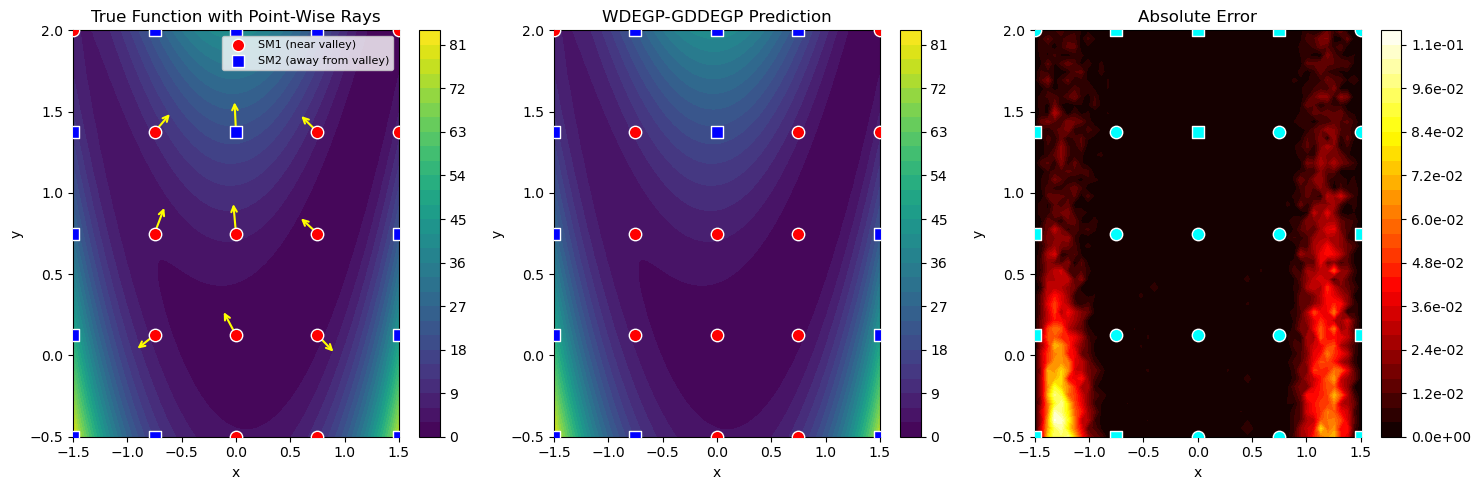

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Reshape for plotting
y_true_grid = y_true.reshape(50, 50)
y_pred_grid = y_pred.reshape(50, 50)
error_grid = np.abs(y_true_grid - y_pred_grid)

# True function with training points and rays
im0 = axes[0].contourf(X1_test, X2_test, y_true_grid, levels=30, cmap='viridis')

# Plot training points colored by submodel
axes[0].scatter(X_train[sm1_indices, 0], X_train[sm1_indices, 1],
                c='red', s=80, marker='o', label='SM1 (near valley)', edgecolors='white', zorder=5)
axes[0].scatter(X_train[sm2_indices, 0], X_train[sm2_indices, 1],
                c='blue', s=80, marker='s', label='SM2 (away from valley)', edgecolors='white', zorder=5)

# Draw gradient direction rays at a subset of points
arrow_scale = 0.2
for i in range(0, num_points):  # Every 3rd point
    color = 'red' if i in sm1_indices else 'blue'
    axes[0].annotate('',
                     xy=(X_train[i, 0] + arrow_scale*rays_dir1_all[0, i],
                         X_train[i, 1] + arrow_scale*rays_dir1_all[1, i]),
                     xytext=(X_train[i, 0], X_train[i, 1]),
                     arrowprops=dict(arrowstyle='->', color='yellow', lw=1.5),
                     annotation_clip=True)

axes[0].set_title('True Function with Point-Wise Rays')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-0.5, 2.0)
plt.colorbar(im0, ax=axes[0])

# GP prediction
im1 = axes[1].contourf(X1_test, X2_test, y_pred_grid, levels=30, cmap='viridis')
axes[1].scatter(X_train[sm1_indices, 0], X_train[sm1_indices, 1],
                c='red', s=80, marker='o', edgecolors='white', zorder=5)
axes[1].scatter(X_train[sm2_indices, 0], X_train[sm2_indices, 1],
                c='blue', s=80, marker='s', edgecolors='white', zorder=5)
axes[1].set_title('WDEGP-GDDEGP Prediction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-0.5, 2.0)
plt.colorbar(im1, ax=axes[1])

# Error
im2 = axes[2].contourf(X1_test, X2_test, error_grid, levels=30, cmap='hot')
axes[2].scatter(X_train[sm1_indices, 0], X_train[sm1_indices, 1],
                c='cyan', s=80, marker='o', edgecolors='white', zorder=5)
axes[2].scatter(X_train[sm2_indices, 0], X_train[sm2_indices, 1],
                c='cyan', s=80, marker='s', edgecolors='white', zorder=5)
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_xlim(-1.5, 1.5)
axes[2].set_ylim(-0.5, 2.0)
plt.colorbar(im2, ax=axes[2], format='%.1e')

plt.tight_layout()
plt.show()

In [73]:
import numpy as np
import warnings
from jetgp.wdegp.wdegp import wdegp
import matplotlib.pyplot as plt

print("Modules imported successfully.")

Modules imported successfully.


In [74]:
np.random.seed(7)

# 3×3 grid — 9 training points
x_vals = np.linspace(0, 1, 3)
X_train = np.array([[x1, x2] for x1 in x_vals for x2 in x_vals])

def f(X):      return np.sin(X[:, 0]) + X[:, 1] ** 2
def df_dx1(X): return np.cos(X[:, 0])
def df_dx2(X): return 2.0 * X[:, 1]

corners = [0, 2, 6, 8]
edges   = [1, 3, 4, 5, 7]   # includes centre

y_all = f(X_train).reshape(-1, 1)

# Submodel 0: f everywhere + df/dx1 at corners
submodel_0 = [y_all, df_dx1(X_train[corners]).reshape(-1, 1)]

# Submodel 1: f everywhere + df/dx1 + df/dx2 at edges
submodel_1 = [y_all,
              df_dx1(X_train[edges]).reshape(-1, 1),
              df_dx2(X_train[edges]).reshape(-1, 1)]

y_train = [submodel_0, submodel_1]

print("Submodel 0: f (9 pts) + df/dx1 (corners, 4 pts)")
print("Submodel 1: f (9 pts) + df/dx1 (edges, 5 pts) + df/dx2 (edges, 5 pts)")
print("df/dx2 is NOT common to all submodels.")

Submodel 0: f (9 pts) + df/dx1 (corners, 4 pts)
Submodel 1: f (9 pts) + df/dx1 (edges, 5 pts) + df/dx2 (edges, 5 pts)
df/dx2 is NOT common to all submodels.


In [75]:
der_indices = [
    [[[[1, 1]]]],              # Submodel 0: dx1 only
    [[[[1, 1]], [[2, 1]]]],    # Submodel 1: dx1 and dx2
]
derivative_locations = [
    [corners],                 # Submodel 0: dx1 at corners
    [edges, edges],            # Submodel 1: dx1 and dx2 at edges
]

print("der_indices          :", der_indices)
print("derivative_locations : submodel 0 →", derivative_locations[0])
print("                       submodel 1 →", derivative_locations[1])

der_indices          : [[[[[1, 1]]]], [[[[1, 1]], [[2, 1]]]]]
derivative_locations : submodel 0 → [[0, 2, 6, 8]]
                       submodel 1 → [[1, 3, 4, 5, 7], [1, 3, 4, 5, 7]]


In [76]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model = wdegp(
        X_train, y_train,
        n_order=1, n_bases=2,
        der_indices=der_indices,
        derivative_locations=derivative_locations,
        normalize=True,
        kernel="SE", kernel_type="anisotropic",
    )

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    params = model.optimize_hyperparameters(
        optimizer="powell", n_restart_optimizer=5, debug=False
    )

print("Optimized hyperparameters:", params)

Optimized hyperparameters: [ -0.90892697  -0.82569414   1.01988072 -12.9310536 ]


In [77]:
np.random.seed(99)
X_test = np.random.uniform(0, 1, (40, 2))

# Request df/dx2 — absent from submodel 0 but present in submodel 1.
# Prior to the update this would have raised a ValueError.
pred = model.predict(
    X_test, params,
    calc_cov=False,
    return_deriv=True,
    derivs_to_predict=[[[2, 1]]]   # dx2
)

# pred shape: (2, n_test) — row 0 = f, row 1 = df/dx2
f_pred   = pred[0, :]
dx2_pred = pred[1, :]

f_true   = f(X_test).flatten()
dx2_true = df_dx2(X_test).flatten()

rmse_f   = float(np.sqrt(np.mean((f_pred - f_true) ** 2)))
rmse_dx2 = float(np.sqrt(np.mean((dx2_pred - dx2_true) ** 2)))
corr_dx2 = float(np.corrcoef(dx2_pred, dx2_true)[0, 1])

print(f"Function RMSE               : {rmse_f:.4e}")
print(f"df/dx2 RMSE (non-common)    : {rmse_dx2:.4e}")
print(f"df/dx2 correlation          : {corr_dx2:.4f}")

Function RMSE               : 3.8033e-04
df/dx2 RMSE (non-common)    : 4.0073e-03
df/dx2 correlation          : 1.0000


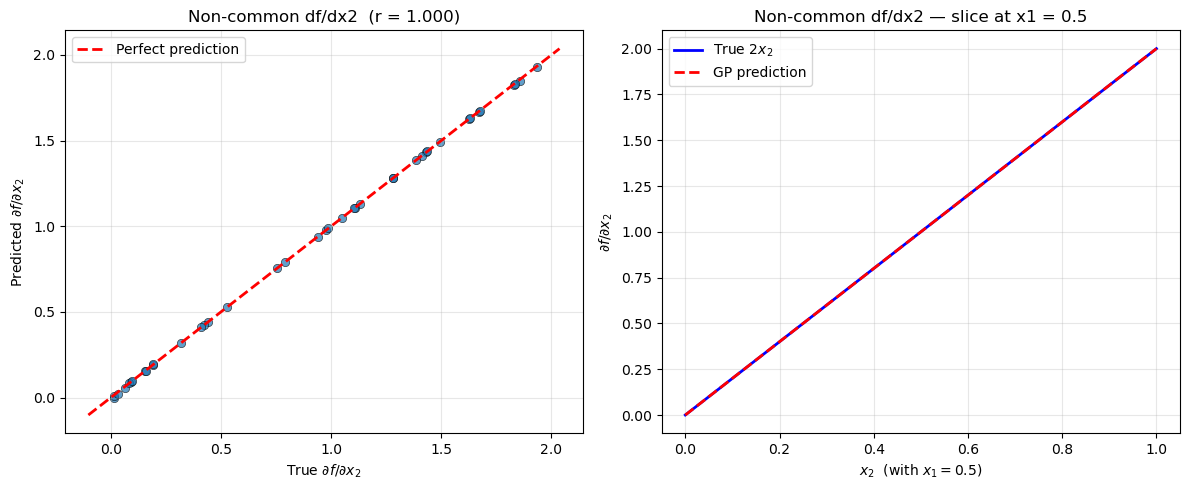

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: predicted vs true df/dx2
axes[0].scatter(dx2_true, dx2_pred, alpha=0.7, edgecolors='k', linewidths=0.5)
lims = [min(dx2_true.min(), dx2_pred.min()) - 0.1,
        max(dx2_true.max(), dx2_pred.max()) + 0.1]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel(r'True $\partial f / \partial x_2$')
axes[0].set_ylabel(r'Predicted $\partial f / \partial x_2$')
axes[0].set_title(f'Non-common df/dx2  (r = {corr_dx2:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Slice along x2 (x1 fixed at 0.5)
x2_line = np.linspace(0, 1, 60)
X_line  = np.column_stack([np.full(60, 0.5), x2_line])
pred_line = model.predict(X_line, params, calc_cov=False,
                          return_deriv=True, derivs_to_predict=[[[2, 1]]])
true_line = df_dx2(X_line).flatten()

axes[1].plot(x2_line, true_line,         'b-',  linewidth=2, label='True $2x_2$')
axes[1].plot(x2_line, pred_line[1, :],   'r--', linewidth=2, label='GP prediction')
axes[1].set_xlabel(r'$x_2$  (with $x_1 = 0.5$)')
axes[1].set_ylabel(r'$\partial f / \partial x_2$')
axes[1].set_title('Non-common df/dx2 — slice at x1 = 0.5')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()